# Final paper analysis: six fixed behavioral metrics

This notebook produces the two comparisons used in the Results section with exactly the same metric definitions:

1. Couzin data vs. Couzin GAIL imitation
2. Biological data vs. Biological GAIL imitation

Predator: normalized predator distance and pursuit alignment. Prey: escape alignment and continuous prey reorientation $R$. Collective: DoS and DoA over a shared $T_{common}$. PIN/AN heat maps remain a separate model-interpretation analysis and are intentionally not mixed into these behavioral comparison tables.

In [9]:
from pathlib import Path
import hashlib, importlib, math, os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython import get_ipython
from IPython.display import display, Markdown

_ipython = get_ipython()
if _ipython is not None:
    _ipython.run_line_magic('matplotlib', 'inline')

ANALYSIS_DIR = Path.cwd().resolve()
if ANALYSIS_DIR.name != 'Paper Analysis':
    ANALYSIS_DIR = ANALYSIS_DIR / 'Paper Analysis'
PROJECT_ROOT = ANALYSIS_DIR.parent
NICOLE_ROOT = PROJECT_ROOT / 'Nicole' / 'Predator-Prey-Thesis'
BIO_WINDOW_ROOT = NICOLE_ROOT / 'Data/1. Data Processing/Processed/video/expert_tensors/windows'
OUTPUT_DIR = ANALYSIS_DIR / os.getenv('PAPER_FINAL_OUTPUT_DIR', 'final_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))
import paper_analysis2 as pa
import final_analysis as fa
pa, fa = importlib.reload(pa), importlib.reload(fa)
print(f'Outputs: {OUTPUT_DIR}')

Outputs: C:\Users\janni\OneDrive\Dokumente\Privat\Bildung\M. Sc. Social and Economic Data Science\Thesis Paper\ICRA2027-PredatorPreyGAIL\Paper Analysis\final_outputs


## Frozen estimands and uncertainty

The independent statistical unit is one trajectory clip, not one frame. The first four metrics are calculated per clip across all genuine frames. For DoS and DoA, one source-specific $T_{common}$ is the largest continuous prefix supported by at least 50% of clips in every one of the four cases and by both metrics. The cohort is then frozen to clips observed throughout that entire prefix. Thus the plotted mean cannot jump merely because short clips disappear. All intervals and differences use a percentile bootstrap that resamples complete clips.

Rollout seeds quantify simulation variability of the available trained checkpoint; they are not training-seed uncertainty. Biological 16-prey data are reconstructed interaction windows, whereas biological 32-prey data are continuous tracks. This limitation should remain explicit when interpreting comparison 3.

In [10]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32
RAW_VIDEO_FPS, BIO_SAMPLING_STRIDE = 30.0, 2
EFFECTIVE_VIDEO_FPS = RAW_VIDEO_FPS / BIO_SAMPLING_STRIDE
STEP_DURATION = {'couzin': 0.5, 'biological': 1.0 / EFFECTIVE_VIDEO_FPS}
D_SOURCE = {'couzin': math.hypot(50, 50), 'biological': math.hypot(2160, 2160)}

APPROACH_DISTANCE_THRESHOLD, APPROACH_EXIT_THRESHOLD = 0.15, 0.165
APPROACH_CLOSING_LAG, APPROACH_MIN_DURATION = 3, 2
APPROACH_COOLDOWN_STEPS = {'couzin': 20, 'biological': 20}
CLOSING_SPEED_LAG, RESPONSE_LAG = 3, 1
RESPONSE_THRESHOLD = 0.10
RESPONSE_THRESHOLD_SENSITIVITY = (0.075, 0.10, 0.125)
RESPONSE_WINDOW_STEPS = {'couzin': 20, 'biological': 20}
TIME_CHUNK_SIZE = 4096

# Risk bins are required internally by analyze_case. They are not the final
# estimands in this notebook and therefore receive no redundant bootstrap.
RISK_RANGES = {'couzin': (0.0144023038, 0.2365715653),
               'biological': (0.0076781777, 0.3913621008)}
N_DISTANCE_BINS, MIN_SAMPLES_PER_BIN, MIN_CLIPS_PER_BIN = 6, 30, 5
RISK_BIN_EDGES = {source: torch.linspace(low, high, N_DISTANCE_BINS + 1,
                                             device=DEVICE, dtype=DTYPE)
                  for source, (low, high) in RISK_RANGES.items()}

ROLLOUT_SEEDS = tuple(int(value) for value in
                      os.getenv('PAPER_FINAL_ROLLOUT_SEEDS', '2027,12027,22027').split(','))
N_ROLLOUTS_PER_SEED = int(os.getenv('PAPER_FINAL_ROLLOUTS_PER_SEED', '10'))
ROLLOUT_STEPS = int(os.getenv('PAPER_FINAL_ROLLOUT_STEPS', '1000'))
N_BOOTSTRAP = int(os.getenv('PAPER_FINAL_N_BOOTSTRAP', '2000'))
CI_LEVEL = 0.95
MIN_SUPPORT_FRACTION = 0.50
WALL_MODE = 'post_step_reflect'

assert len(set(ROLLOUT_SEEDS)) == len(ROLLOUT_SEEDS) and N_ROLLOUTS_PER_SEED > 0
assert ROLLOUT_STEPS > 1 and N_BOOTSTRAP > 0
display({'device': str(DEVICE), 'rollout_seeds': ROLLOUT_SEEDS,
         'rollouts_per_seed': N_ROLLOUTS_PER_SEED, 'rollout_steps': ROLLOUT_STEPS,
         'clip_bootstrap_replicates': N_BOOTSTRAP, 'biological_effective_fps': EFFECTIVE_VIDEO_FPS})

{'device': 'cuda',
 'rollout_seeds': (2027, 12027, 22027),
 'rollouts_per_seed': 10,
 'rollout_steps': 1000,
 'clip_bootstrap_replicates': 2000,
 'biological_effective_fps': 15.0}

## Load data and generate matched rollouts

All environment settings are explicit. Biological imitation rollouts start only from the interaction partition of the original initialization pools. Couzin imitation rollouts start from the generated Couzin expert trajectories. The corrected post-step wall reflection is used throughout.

In [11]:
COUZIN_POLICY = {
    'root': NICOLE_ROOT, 'code_subdir': '.',
    'prey_checkpoint': 'Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16/prey_policy_stage1.pth',
    'pred_checkpoint': 'Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16/pred_policy_stage1.pth',
    'prey_features': 6, 'pred_features': 5, 'deterministic': False,
    'environment': {'area_width': 50, 'area_height': 50, 'prey_speed': 5, 'pred_speed': 5,
                    'step_size': 0.5, 'max_turn': 0.25, 'max_speed_norm': 5.0},
}
COUZIN_DYNAMICS = {'dt': 0.5, 'alpha': 0.1, 'theta_dot_max': 0.5,
                   'theta_dot_max_shark': 0.5, 'constant_speed': 5.0, 'shark_speed': 5.0}
BIO_POLICY = {
    'root': NICOLE_ROOT, 'code_subdir': '.',
    'prey_checkpoint': 'Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16/prey_policy_stage1.pth',
    'pred_checkpoint': 'Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16/pred_policy_stage1.pth',
    'prey_features': 6, 'pred_features': 5, 'deterministic': False,
    'environment': {'area_width': 2160, 'area_height': 2160, 'prey_speed': 10, 'pred_speed': 10,
                    'step_size': 1.0, 'max_turn': 0.314, 'max_speed_norm': 25.0},
}
assert math.isclose(COUZIN_POLICY['environment']['step_size'], COUZIN_DYNAMICS['dt'])
assert math.isclose(COUZIN_POLICY['environment']['max_turn'],
                    COUZIN_DYNAMICS['dt'] * COUZIN_DYNAMICS['theta_dot_max'])

BIO_EXPERT_ROOT_32 = NICOLE_ROOT / 'Data/1. Data Processing/Processed/video/expert_tensors/32_prey_interactions/2. filtered_frames'
INIT_POOL_PATHS = {n: NICOLE_ROOT / f'Data/1. Data Processing/Processed/init_pool/init_pool_{n}prey.pt'
                   for n in (16, 32)}
INIT_POOL_PARTITIONS = {16: {'interaction': (0, 1619), 'attack': (1619, 3293)},
                        32: {'interaction': (0, 24), 'attack': (24, 1081)}}

def load_tensor(path):
    try:
        return torch.load(path, map_location='cpu', weights_only=True)
    except (TypeError, RuntimeError):
        return torch.load(path, map_location='cpu', weights_only=False)

BIO_INTERACTION_POOLS = {}
for n, path in INIT_POOL_PATHS.items():
    pool = load_tensor(path)
    start, stop = INIT_POOL_PARTITIONS[n]['interaction']
    assert tuple(pool.shape[1:]) == (n + 1, 3)
    assert len(pool) == INIT_POOL_PARTITIONS[n]['attack'][1]
    BIO_INTERACTION_POOLS[n] = pool[start:stop].clone()

case_specs = {
    **{f'couzin_expert_{n}': {'source': 'couzin', 'kind': 'couzin_expert', 'n_prey': n}
       for n in (16, 32)},
    **{f'couzin_imitation_{n}': {'source': 'couzin', 'kind': 'imitation', 'n_prey': n,
                                  'policy': COUZIN_POLICY} for n in (16, 32)},
    **{f'bio_expert_{n}': {'source': 'biological', 'kind': 'bio_expert', 'n_prey': n}
       for n in (16, 32)},
    **{f'bio_imitation_{n}': {'source': 'biological', 'kind': 'imitation', 'n_prey': n,
                               'policy': BIO_POLICY} for n in (16, 32)},
}

cases, case_diagnostics = {}, {}
for name, spec in tqdm(case_specs.items(), desc='Loading/generating final cases'):
    n, source = spec['n_prey'], spec['source']
    if spec['kind'] == 'couzin_expert':
        table = pa.generate_couzin_expert_rollouts(
            NICOLE_ROOT, n_prey=n, n_rollouts=N_ROLLOUTS_PER_SEED,
            rollout_steps=ROLLOUT_STEPS, seed=ROLLOUT_SEEDS[0], rollout_seeds=ROLLOUT_SEEDS,
            area_width=50, area_height=50, wall_mode=WALL_MODE, **COUZIN_DYNAMICS)
    elif spec['kind'] == 'bio_expert' and n == 16:
        table = pa.load_biological_window_trajectories(
            BIO_WINDOW_ROOT, n_prey=16, condition='interaction', coordinate_scale=2160,
            effective_fps=EFFECTIVE_VIDEO_FPS, sampling_stride=BIO_SAMPLING_STRIDE)
    elif spec['kind'] == 'bio_expert':
        table = pa.load_expert_trajectories(
            BIO_EXPERT_ROOT_32, n_prey=32, condition='interaction', image_y_down=True,
            coordinate_height=2160, role_map={'1': 'predator', '2': 'prey'},
            require_complete_frames=True, fps=EFFECTIVE_VIDEO_FPS)
        table = pa.with_constant_metadata(
            table, fps=EFFECTIVE_VIDEO_FPS, step_duration=STEP_DURATION['biological'],
            sampling_stride=BIO_SAMPLING_STRIDE)
    else:
        policy = spec['policy']
        init_pool = (pa.initial_state_pool_from_trajectory(cases[f'couzin_expert_{n}'],
                                                               expected_n_prey=n)
                     if source == 'couzin' else BIO_INTERACTION_POOLS[n])
        table = pa.generate_policy_rollouts(
            policy, policy['root'], n_prey=n, n_rollouts=N_ROLLOUTS_PER_SEED,
            rollout_steps=ROLLOUT_STEPS, seed=ROLLOUT_SEEDS[0], rollout_seeds=ROLLOUT_SEEDS,
            init_pool_tensor=init_pool,
            condition='interaction' if source == 'biological' else 'approach',
            effective_fps=EFFECTIVE_VIDEO_FPS if source == 'biological' else None,
            sampling_stride=BIO_SAMPLING_STRIDE if source == 'biological' else 1,
            wall_mode=WALL_MODE)

    diagnostics = pa.trajectory_diagnostics(table)
    if diagnostics['prey_per_frame_min'] != n or diagnostics['prey_per_frame_max'] != n:
        raise ValueError(f'{name}: expected exactly {n} prey per frame; got {diagnostics}')
    for field in ('x', 'y', 'heading'):
        if not np.all(np.isfinite(table[field])):
            raise ValueError(f'{name}: non-finite {field}')
    cases[name], case_diagnostics[name] = table, diagnostics

required_cases = set(name for names in fa.SOURCE_CASES.values() for name in names)
assert set(cases) == required_cases, f'Missing cases: {sorted(required_cases - set(cases))}'
display(pd.DataFrame.from_dict(case_diagnostics, orient='index'))

Loading/generating final cases: 100%|██████████| 8/8 [15:28<00:00, 116.02s/it]


,rows,clips_or_rollouts,frames,prey_per_frame_min,prey_per_frame_max,x_range,y_range,heading_range,conditions,fps_values,step_duration_values,rollout_replicate_seeds,independent_simulation_seeds,wall_modes,timestep_status
couzin_expert_16,510000,30,30000,16,16,"(0.0, 50.0)","(0.0, 50.0)","(-3.141592653589793, 3.1415734400929516)",{'approach': 510000},[],[0.5],"[2027, 12027, 22027]",30,[post_step_reflect],explicit step duration
couzin_expert_32,990000,30,30000,32,32,"(0.0, 50.0)","(0.0, 50.0)","(-3.141592653589793, 3.1415866168658075)",{'approach': 990000},[],[0.5],"[2027, 12027, 22027]",30,[post_step_reflect],explicit step duration
couzin_imitation_16,510000,30,30000,16,16,"(0.0, 50.0)","(0.0, 50.0)","(-3.141589879989624, 3.141587018966675)",{'approach': 510000},[],[0.5],"[2027, 12027, 22027]",30,[post_step_reflect],explicit step duration
couzin_imitation_32,990000,30,30000,32,32,"(0.0, 50.0)","(0.0, 50.0)","(-3.1415839195251465, 3.141584634780884)",{'approach': 990000},[],[0.5],"[2027, 12027, 22027]",30,[post_step_reflect],explicit step duration
bio_expert_16,27523,8,1619,16,16,"(-1693.357421875, 1673.1080322265625)","(-1280.291748046875, 1316.9178466796875)","(-3.141592264175415, 3.141592566167013)",{'interaction': 27523},[15.0],[0.06666666666666667],[],0,[],explicit step duration
bio_expert_32,392007,35,11879,32,32,"(12.856284846417006, 2160.2542277168986)","(0.0, 2146.369623144862)","(-3.14158531800636, 3.141589390613703)",{'interaction': 392007},[15.0],[0.06666666666666667],[],0,[],explicit step duration
bio_imitation_16,510000,30,30000,16,16,"(0.0, 2160.0)","(0.0, 2160.0)","(-3.1415786743164062, 3.1415908336639404)",{'interaction': 510000},[15.0],[0.06666666666666667],"[2027, 12027, 22027]",30,[post_step_reflect],explicit step duration
bio_imitation_32,990000,30,30000,32,32,"(0.0, 2160.0)","(0.0, 2160.0)","(-3.141592264175415, 3.141592502593994)",{'interaction': 990000},[15.0],[0.06666666666666667],"[2027, 12027, 22027]",30,[post_step_reflect],explicit step duration


## Compute clip-level metrics

The canonical implementation in `paper_analysis2.py` computes the geometry once for each case. Bootstrap intervals for unused exploratory risk curves are disabled here; the selected final estimands are bootstrapped below in `final_analysis.py`.

In [12]:
case_results = {}
with torch.inference_mode():
    for name, table in tqdm(cases.items(), desc='Computing final metrics'):
        source = case_specs[name]['source']
        case_results[name] = pa.analyze_case(
            table, d_source=D_SOURCE[source], risk_bin_edges=RISK_BIN_EDGES[source],
            expected_n_prey=case_specs[name]['n_prey'], device=DEVICE, dtype=DTYPE,
            time_chunk_size=TIME_CHUNK_SIZE,
            approach_distance_threshold=APPROACH_DISTANCE_THRESHOLD,
            approach_exit_threshold=APPROACH_EXIT_THRESHOLD,
            approach_closing_lag=APPROACH_CLOSING_LAG,
            approach_min_duration=APPROACH_MIN_DURATION,
            approach_cooldown_steps=APPROACH_COOLDOWN_STEPS[source],
            require_target_persistence=True, closing_speed_lag=CLOSING_SPEED_LAG,
            response_threshold=RESPONSE_THRESHOLD,
            response_threshold_sensitivity=RESPONSE_THRESHOLD_SENSITIVITY,
            response_window_steps=RESPONSE_WINDOW_STEPS[source], response_lag=RESPONSE_LAG,
            min_bin_count=MIN_SAMPLES_PER_BIN, min_cluster_count=MIN_CLIPS_PER_BIN,
            n_bootstrap=0, ci_level=CI_LEVEL, bootstrap_seed=ROLLOUT_SEEDS[0],
            step_duration=STEP_DURATION[source])

final_results = fa.build_final_results(
    case_results, step_duration=STEP_DURATION, min_support_fraction=MIN_SUPPORT_FRACTION,
    n_bootstrap=N_BOOTSTRAP, ci_level=CI_LEVEL, seed=ROLLOUT_SEEDS[0])

support_table = pd.DataFrame(final_results['support'])
support_table.to_csv(OUTPUT_DIR / 't_common_support_audit.csv', index=False)
display(Markdown(f"**Shared horizons:** Couzin $T_{{common}}={final_results['settings']['T_common']['couzin']}$ steps; "
                 f"biological $T_{{common}}={final_results['settings']['T_common']['biological']}$ steps "
                 f"({final_results['settings']['T_common']['biological']/EFFECTIVE_VIDEO_FPS:.2f} s)."))
display(support_table)
display({'geometry_sanity_tests': pa.run_geometry_sanity_tests()})

Computing final metrics: 100%|██████████| 8/8 [03:35<00:00, 26.95s/it]


**Shared horizons:** Couzin $T_{common}=999$ steps; biological $T_{common}=186$ steps (12.40 s).

,metric,source,case,T_common_step,T_common_time,case_last_supported_step,required_clips,complete_prefix_clips,original_clips,complete_prefix_fraction
0,dos,couzin,couzin_expert_16,999,499.5,999,15,30,30,1.000000
1,dos,couzin,couzin_expert_32,999,499.5,999,15,30,30,1.000000
2,dos,couzin,couzin_imitation_16,999,499.5,999,15,30,30,1.000000
3,dos,couzin,couzin_imitation_32,999,499.5,999,15,30,30,1.000000
4,dos,biological,bio_expert_16,186,12.4,186,4,5,8,0.625000
5,dos,biological,bio_expert_32,186,12.4,213,18,19,35,0.542857
6,dos,biological,bio_imitation_16,186,12.4,999,15,30,30,1.000000
7,dos,biological,bio_imitation_32,186,12.4,999,15,30,30,1.000000
8,doa,couzin,couzin_expert_16,999,499.5,999,15,30,30,1.000000
9,doa,couzin,couzin_expert_32,999,499.5,999,15,30,30,1.000000


{'geometry_sanity_tests': {'wrap_pi': True,
  'predator_ahead': True,
  'predator_left': True,
  'predator_right': True,
  'left_turn_positive': True,
  'right_turn_negative': True,
  'polarization_aligned': True,
  'polarization_opposed': True,
  'known_nnd': True,
  'closer_risk_distance': True,
  'away_response_positive': True,
  'km_handles_censoring': True,
  'approach_hysteresis_prevents_flicker': True}}

## Stage 1 — Couzin data vs. Couzin GAIL imitation

Predator and Prey are exported as two separate, compact figures because they are discussed independently in the paper. Each figure contains two grouped boxplots for 16 and 32 prey. Boxes summarize the clip-level distributions, while the overlaid points retain every independent clip. DoS and DoA are kept separate as a third Collective Response figure.

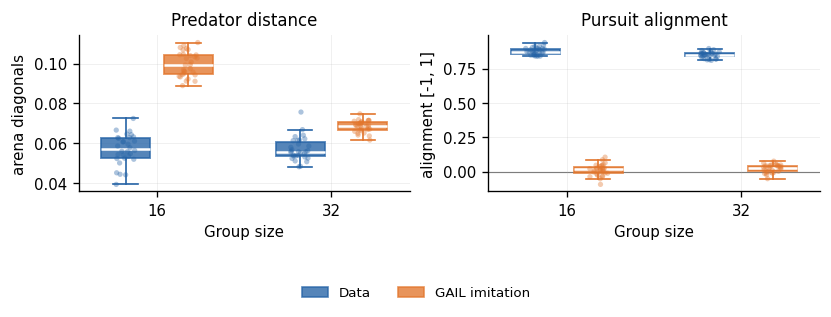

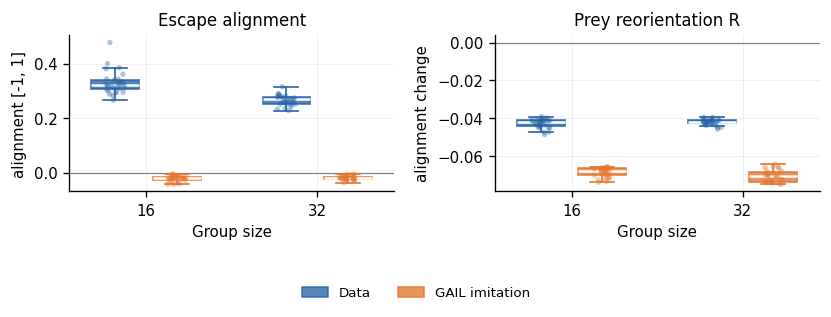

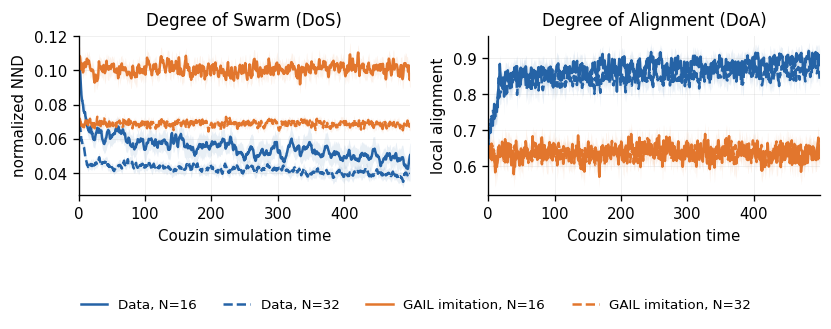

,Category,Metric,N,Data mean [95% CI],GAIL mean [95% CI],GAIL - Data [95% CI],Absolute error,Clips Data/GAIL
0,Predator,Normalized predator distance,16,"0.057 [0.054, 0.060]","0.100 [0.098, 0.102]","0.043 [0.039, 0.046]",0.043,30/30
1,Predator,Normalized predator distance,32,"0.057 [0.055, 0.059]","0.069 [0.068, 0.070]","0.011 [0.009, 0.014]",0.011,30/30
2,Predator,Pursuit alignment,16,"0.878 [0.869, 0.887]","0.012 [-0.003, 0.026]","-0.866 [-0.883, -0.849]",0.866,30/30
3,Predator,Pursuit alignment,32,"0.851 [0.843, 0.859]","0.022 [0.012, 0.032]","-0.829 [-0.842, -0.816]",0.829,30/30
4,Prey,Escape alignment,16,"0.329 [0.316, 0.345]","-0.022 [-0.025, -0.018]","-0.351 [-0.368, -0.337]",0.351,30/30
5,Prey,Escape alignment,32,"0.266 [0.259, 0.272]","-0.019 [-0.021, -0.016]","-0.285 [-0.292, -0.278]",0.285,30/30
6,Prey,Continuous prey reorientation R,16,"-0.043 [-0.044, -0.042]","-0.069 [-0.070, -0.068]","-0.026 [-0.027, -0.025]",0.026,30/30
7,Prey,Continuous prey reorientation R,32,"-0.042 [-0.043, -0.042]","-0.070 [-0.071, -0.069]","-0.028 [-0.029, -0.027]",0.028,30/30
8,Collective,"Degree of Swarm (DoS), T-common",16,"0.055 [0.052, 0.058]","0.101 [0.100, 0.101]","0.045 [0.043, 0.049]",0.045,30/30
9,Collective,"Degree of Swarm (DoS), T-common",32,"0.043 [0.041, 0.044]","0.069 [0.069, 0.069]","0.026 [0.025, 0.028]",0.026,30/30


In [13]:
for category in ('Predator', 'Prey'):
    fig = fa.plot_source_overview(final_results, 'couzin', category)
    fa.save_figure(fig, OUTPUT_DIR / f'stage1_couzin_{category.lower()}_boxplots')
    plt.show(); plt.close(fig)

fig = fa.plot_collective_timeline(final_results, 'couzin')
fa.save_figure(fig, OUTPUT_DIR / 'stage1_couzin_collective_tcommon')
plt.show(); plt.close(fig)

stage1_rows = fa.stage_imitation_table(final_results, 'couzin')
stage1_numeric = pd.DataFrame(stage1_rows)
stage1_paper = fa.paper_imitation_table(stage1_rows)
stage1_numeric.to_csv(OUTPUT_DIR / 'stage1_couzin_data_vs_gail_numeric.csv', index=False)
fa.save_table_artifacts(stage1_paper, OUTPUT_DIR / 'stage1_couzin_data_vs_gail_paper_table')
display(stage1_paper)

## Stage 2 — Biological data vs. Biological GAIL imitation

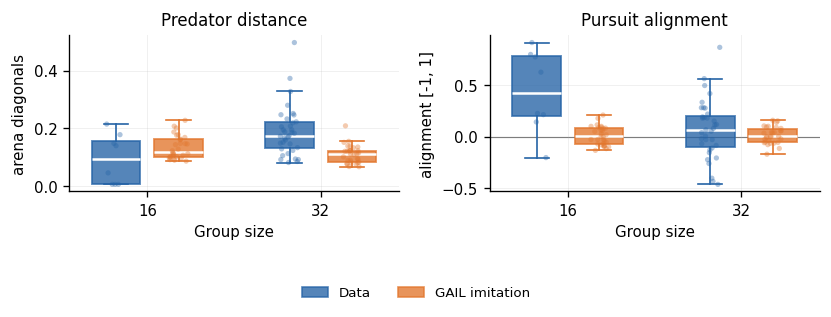

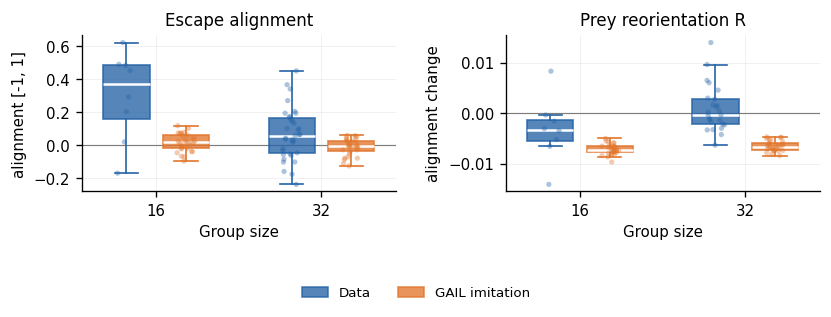

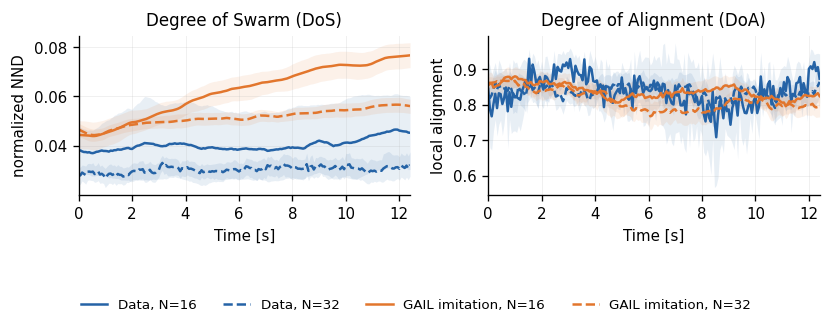

,Category,Metric,N,Data mean [95% CI],GAIL mean [95% CI],GAIL - Data [95% CI],Absolute error,Clips Data/GAIL
0,Predator,Normalized predator distance,16,"0.093 [0.034, 0.150]","0.134 [0.121, 0.148]","0.041 [-0.014, 0.095]",0.041,8/30
1,Predator,Normalized predator distance,32,"0.188 [0.162, 0.218]","0.111 [0.101, 0.122]","-0.078 [-0.108, -0.049]",0.078,35/30
2,Predator,Pursuit alignment,16,"0.439 [0.173, 0.689]","0.009 [-0.021, 0.042]","-0.430 [-0.679, -0.160]",0.430,8/30
3,Predator,Pursuit alignment,32,"0.073 [-0.022, 0.160]","0.016 [-0.012, 0.044]","-0.056 [-0.156, 0.041]",0.056,35/30
4,Prey,Escape alignment,16,"0.299 [0.128, 0.474]","0.016 [-0.003, 0.034]","-0.283 [-0.453, -0.095]",0.283,8/30
5,Prey,Escape alignment,32,"0.065 [0.015, 0.115]","-0.012 [-0.029, 0.005]","-0.077 [-0.129, -0.022]",0.077,35/30
6,Prey,Continuous prey reorientation R,16,"-0.003 [-0.007, 0.001]","-0.007 [-0.008, -0.007]","-0.004 [-0.008, 0.000]",0.004,8/30
7,Prey,Continuous prey reorientation R,32,"0.001 [-0.001, 0.003]","-0.007 [-0.007, -0.006]","-0.007 [-0.009, -0.006]",0.007,25/30
8,Collective,"Degree of Swarm (DoS), T-common",16,"0.040 [0.028, 0.056]","0.062 [0.058, 0.066]","0.022 [0.007, 0.035]",0.022,5/30
9,Collective,"Degree of Swarm (DoS), T-common",32,"0.030 [0.027, 0.033]","0.051 [0.049, 0.053]","0.021 [0.017, 0.025]",0.021,19/30


In [14]:
for category in ('Predator', 'Prey'):
    fig = fa.plot_source_overview(final_results, 'biological', category)
    fa.save_figure(fig, OUTPUT_DIR / f'stage2_bio_{category.lower()}_boxplots')
    plt.show(); plt.close(fig)

fig = fa.plot_collective_timeline(final_results, 'biological')
fa.save_figure(fig, OUTPUT_DIR / 'stage2_bio_collective_tcommon')
plt.show(); plt.close(fig)

stage2_rows = fa.stage_imitation_table(final_results, 'biological')
stage2_numeric = pd.DataFrame(stage2_rows)
stage2_paper = fa.paper_imitation_table(stage2_rows)
stage2_numeric.to_csv(OUTPUT_DIR / 'stage2_bio_data_vs_gail_numeric.csv', index=False)
fa.save_table_artifacts(stage2_paper, OUTPUT_DIR / 'stage2_bio_data_vs_gail_paper_table')
display(stage2_paper)

## Final paper tables

These are the two tables intended for direct transfer to the Results section. Values are means with 95% clip-bootstrap confidence intervals. Exact unrounded values are stored in the corresponding `*_numeric.csv` files; the formatted versions are exported as CSV and LaTeX.

In [ ]:
display(Markdown('### Table 1 — Couzin data vs. Couzin GAIL imitation'))
display(stage1_paper)
display(Markdown('### Table 2 — Biological data vs. Biological GAIL imitation'))
display(stage2_paper)

artifact_manifest = pd.DataFrame({
    'artifact': sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file()),
})
display(Markdown(f'All final artifacts were written to `{OUTPUT_DIR}`.'))
display(artifact_manifest)

## Suggested caption and reporting note

**Predator/Prey figures:** Comparison of Couzin/biological reference trajectories and GAIL-generated trajectories at group sizes 16 and 32. Boxes show the median and interquartile range of the independent clip values, whiskers extend to 1.5 times the interquartile range, and transparent points show every clip.

**Collective time courses:** DoS and DoA trajectories use a source-specific common horizon and a fixed complete-prefix clip cohort. Shaded bands are 95% clip-bootstrap confidence intervals.
